# ML4QS Group 40 — Preprocessing Pipeline
**Wrist-Based Activity Recognition**  
Aniket Dasurkar, Mansi Saxena, Shreya Bhatt — Vrije Universiteit Amsterdam

This notebook covers:
1. Load & merge all 3 sensor streams
2. Symmetric trim to 30 s
3. Missing value detection & interpolation
4. Outlier detection & handling (physical limits + z-score)
5. Granularity / resampling — noise reduction by changing resolution
6. Low-pass Butterworth filter
7. Magnitude columns
8. Z-score normalisation (per subject, fit on train only)
9. Train / test split — subject_1 + subject_3 → train, subject_2 → test
10. Sanity checks & summary stats
11. Visualisations — before/after, sampling rate, outlier distributions


## 0 · Imports & Constants

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy.signal import butter, filtfilt, welch
from scipy.stats import zscore

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("../data/raw/")
OUTPUT_DIR = Path("../outputs/")
(OUTPUT_DIR / "eda").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "features").mkdir(parents=True, exist_ok=True)

# ── Dataset constants ──────────────────────────────────────────────────────────
SUBJECTS       = ["subject_1", "subject_2", "subject_3"]
ACTIVITIES     = ["smoking", "typing", "idle", "cooking", "exercising"]
SENSOR_COLS    = ["acc_x","acc_y","acc_z",
                  "gyr_x","gyr_y","gyr_z",
                  "lin_x","lin_y","lin_z"]
TARGET_SECONDS = 30.0
PALETTE        = dict(zip(ACTIVITIES,
                          ["#e63946","#457b9d","#6a994e","#e9c46a","#f4a261"]))

print("✅ Imports done")


✅ Imports done


## 1 · Load & Merge Sensor Streams

Each Phyphox session folder contains three CSVs — `Accelerometer.csv`, `Gyroscope.csv`, and `Linear Accelerometer.csv`. Each sensor has its own internal clock and does not sample at exactly the same instants, so we merge them using `merge_asof` (nearest-timestamp join with 10 ms tolerance) rather than a regular merge which would discard most rows.


In [47]:
def load_session(session_dir: Path) -> pd.DataFrame:
    acc = pd.read_csv(session_dir / "Accelerometer.csv")
    gyr = pd.read_csv(session_dir / "Gyroscope.csv")
    lin = pd.read_csv(session_dir / "Linear Accelerometer.csv")

    acc.columns = ["time", "acc_x", "acc_y", "acc_z"]
    gyr.columns = ["time", "gyr_x", "gyr_y", "gyr_z"]
    lin.columns = ["time", "lin_x", "lin_y", "lin_z"]

    for _df in [acc, gyr, lin]:
        _df.sort_values("time", inplace=True)
        _df.reset_index(drop=True, inplace=True)

    df = pd.merge_asof(acc, gyr, on="time", direction="nearest", tolerance=0.010)
    df = pd.merge_asof(df,  lin, on="time", direction="nearest", tolerance=0.010)
    return df


def load_all_sessions(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    records = []
    for subject in SUBJECTS:
        subject_dir = data_dir / subject
        if not subject_dir.exists():
            print(f"⚠️  {subject} not found — skipping")
            continue
        for activity_dir in sorted(subject_dir.iterdir()):
            if not activity_dir.is_dir():
                continue
            for session_dir in sorted(activity_dir.iterdir()):
                if not session_dir.is_dir():
                    continue
                try:
                    df = load_session(session_dir)
                    df["subject"]  = subject
                    df["activity"] = activity_dir.name
                    df["session"]  = session_dir.name
                    records.append(df)
                except FileNotFoundError as e:
                    print(f"  ❌ Missing file: {e}")
                except Exception as e:
                    print(f"  ❌ Error in {session_dir}: {e}")

    full = pd.concat(records, ignore_index=True)
    print(f"✅ Loaded {len(records)} sessions | {len(full):,} rows total")
    return full


df_raw = load_all_sessions()
df_raw.head()


✅ Loaded 120 sessions | 1,089,989 rows total


,time,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,lin_x,lin_y,lin_z,subject,activity,session
0,-0.001668,6.207741,-3.733835,6.260581,NaN,NaN,NaN,NaN,NaN,NaN,subject_1,cooking,session_01
1,0.008271,6.453979,-3.687881,6.322402,-0.006524,0.067063,0.023213,-0.295178,0.289950,0.441830,subject_1,cooking,session_01
2,0.018209,6.646778,-3.730991,6.235733,0.011246,0.087129,-0.000061,-0.101705,0.231164,0.344300,subject_1,cooking,session_01
3,0.028148,6.671776,-3.811225,6.330935,0.023503,0.075514,-0.014563,-0.087645,0.145950,0.431305,subject_1,cooking,session_01
4,0.038087,6.539451,-3.819158,6.399492,0.024654,0.053258,-0.006519,-0.208959,0.138356,0.457965,subject_1,cooking,session_01


## 2 · Symmetric Trim to 30 s

Raw recordings vary from 32–62 s due to manual start/stop. The boundaries contain artefacts (getting ready, reaching for the phone) that are not representative of the activity. We cut **equal amounts from both ends** so the remaining clip is exactly 30 s — this avoids biasing the signal toward the start or end of the activity.


In [48]:
def trim_to_duration(df: pd.DataFrame, target: float = TARGET_SECONDS) -> pd.DataFrame:
    duration = df["time"].max() - df["time"].min()
    excess   = duration - target

    if excess < 0:
        print(f"  ⚠️  Only {duration:.1f}s — shorter than target, keeping as-is")
        return df

    cut = excess / 2.0
    t0  = df["time"].min() + cut
    t1  = df["time"].max() - cut

    trimmed = df[(df["time"] >= t0) & (df["time"] <= t1)].copy()
    trimmed["time"] = trimmed["time"] - trimmed["time"].min()
    return trimmed.reset_index(drop=True)

def apply_trim(df: pd.DataFrame) -> pd.DataFrame:
    results = []
    for subject in df["subject"].unique():
        for activity in df["activity"].unique():
            for session in df["session"].unique():
                mask = (
                    (df["subject"]  == subject) &
                    (df["activity"] == activity) &
                    (df["session"]  == session)
                )
                group = df[mask].copy()
                if len(group) == 0:
                    continue
                trimmed = trim_to_duration(group)
                trimmed["subject"]  = subject
                trimmed["activity"] = activity
                trimmed["session"]  = session
                results.append(trimmed)
    return pd.concat(results, ignore_index=True)

df = apply_trim(df_raw)

print(df.columns.tolist())
print(df.groupby("subject").size())

durations = df.groupby(["subject","activity","session"])["time"].max()
print(f"Duration after trim — min: {durations.min():.2f}s  "
      f"max: {durations.max():.2f}s  mean: {durations.mean():.2f}s")
print(f"Sessions: {durations.shape[0]}  (expected 120)")

['time', 'acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z', 'lin_x', 'lin_y', 'lin_z', 'subject', 'activity', 'session']
subject
subject_1    120739
subject_2    120065
subject_3    599991
dtype: int64
Duration after trim — min: 29.98s  max: 30.00s  mean: 29.99s
Sessions: 120  (expected 120)


In [49]:
df.shape

(840795, 13)

## 3 · Missing Value Detection & Interpolation

NaN values can be introduced at the edges of the `merge_asof` join if a sensor has no sample within the 10 ms tolerance window. We check for these and repair them with **linear interpolation** along the time axis.

**Why linear interpolation** (ML4QS Ch. 3): IMU signals are smooth and gaps are at most one sample wide (~10 ms). Linear interpolation is appropriate here — more complex methods (spline, KNN) would be overkill for such short gaps. Forward/back-fill handles any residual NaNs at the very edges where interpolation cannot operate.


In [50]:
def handle_missing(df: pd.DataFrame) -> pd.DataFrame:
    nan_counts = df[SENSOR_COLS].isnull().sum()
    total_nans = nan_counts.sum()

    if total_nans == 0:
        print("✅ No missing values found")
        return df

    print(f"⚠️  {total_nans} NaNs detected:")
    print(nan_counts[nan_counts > 0])

    results = []
    for subject in df["subject"].unique():
        for activity in df["activity"].unique():
            for session in df["session"].unique():
                mask = (
                    (df["subject"]  == subject) &
                    (df["activity"] == activity) &
                    (df["session"]  == session)
                )
                grp = df[mask].copy()
                if len(grp) == 0:
                    continue
                grp[SENSOR_COLS] = (grp[SENSOR_COLS]
                                    .interpolate(method="linear", limit_direction="both")
                                    .ffill().bfill())
                grp["subject"]  = subject
                grp["activity"] = activity
                grp["session"]  = session
                results.append(grp)

    df_out = pd.concat(results, ignore_index=True)
    remaining = df_out[SENSOR_COLS].isnull().sum().sum()
    print(f"  → After interpolation: {remaining} NaNs remaining")
    return df_out

df = handle_missing(df)

⚠️  27 NaNs detected:
lin_x    9
lin_y    9
lin_z    9
dtype: int64
  → After interpolation: 0 NaNs remaining


In [51]:
df.shape

(840795, 13)

## 4 · Outlier Detection & Handling

Two-pass approach (ML4QS Ch. 3):

**Pass 1 — Physical plausibility check:** Any accelerometer value above 80 m/s² (~8g) or gyroscope above 35 rad/s is physically impossible for deliberate wrist motion and almost certainly indicates the phone being dropped or a sensor glitch.

**Pass 2 — Per-session z-score:** Within each 30-second session, values beyond ±5σ are treated as spike artefacts. The 5σ threshold is deliberately conservative — we do not want to suppress genuine high-energy exercising motion, only true spikes.

Detected outliers are **replaced with NaN and re-interpolated** rather than the rows being dropped, because dropping rows would break the uniform time grid required for windowing and FFT.


In [52]:
print(df.columns.tolist())
print(df.shape)
print(df.head(2))

['time', 'acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z', 'lin_x', 'lin_y', 'lin_z', 'subject', 'activity', 'session']
(840795, 13)
       time     acc_x     acc_y     acc_z     gyr_x     gyr_y     gyr_z  \
0  0.000000  7.801327 -6.339617  0.721799  0.218310  1.717028  0.084165   
1  0.009938  6.750812 -6.047275  0.109273  0.263777  1.717073  0.212756   

      lin_x     lin_y     lin_z    subject activity     session  
0  0.089139 -0.063659  0.815572  subject_1  cooking  session_01  
1 -0.935348  0.198704  0.127106  subject_1  cooking  session_01  


In [53]:
def detect_and_handle_outliers(df: pd.DataFrame,
                                acc_threshold: float = 80.0,
                                gyr_threshold: float = 35.0,
                                zscore_threshold: float = 5.0) -> pd.DataFrame:
    results = []
    total_phys   = 0
    total_zscore = 0

    for (subject, activity, session), group in df.groupby(["subject","activity","session"]):
        grp = group.copy()

        # ── Pass 1: Physical limits ───────────────────────────────────────
        acc_mask  = (grp[["acc_x","acc_y","acc_z"]].abs() > acc_threshold).any(axis=1)
        gyr_mask  = (grp[["gyr_x","gyr_y","gyr_z"]].abs() > gyr_threshold).any(axis=1)
        phys_mask = acc_mask | gyr_mask
        total_phys += phys_mask.sum()
        grp.loc[phys_mask, SENSOR_COLS] = np.nan

        # ── Pass 2: Per-session z-score ───────────────────────────────────
        for col in SENSOR_COLS:
            valid   = grp[col].dropna()
            if len(valid) < 4:
                continue
            z       = np.abs(zscore(valid))
            bad_idx = valid.index[z > zscore_threshold]
            total_zscore += len(bad_idx)
            grp.loc[bad_idx, col] = np.nan

        # Re-attach labels
        grp["subject"]  = subject
        grp["activity"] = activity
        grp["session"]  = session

        # Interpolate NaNs introduced above
        grp[SENSOR_COLS] = (grp[SENSOR_COLS]
                            .interpolate(method="linear", limit_direction="both")
                            .ffill().bfill())
        results.append(grp)

    df_out = pd.concat(results, ignore_index=True)
    print(f"Pass 1 — Physical outliers:              {total_phys}")
    print(f"Pass 2 — Statistical outliers (>{zscore_threshold}σ): {total_zscore}")
    print(f"✅ Total outliers handled: {total_phys + total_zscore} "
          f"({100*(total_phys+total_zscore)/len(df_out):.3f}% of rows)")
    return df_out


df = detect_and_handle_outliers(df)

Pass 1 — Physical outliers:              0
Pass 2 — Statistical outliers (>5.0σ): 8807
✅ Total outliers handled: 8807 (1.047% of rows)


### 4.1 · Visualise — Z-score Distributions Per Activity

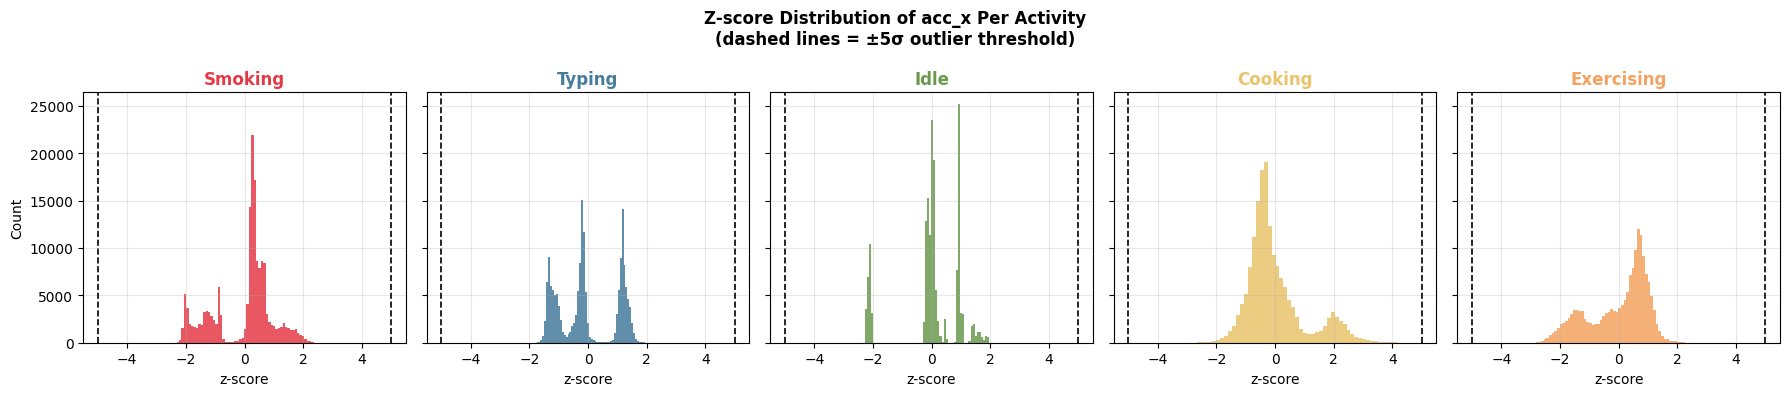

In [54]:
fig, axes = plt.subplots(1, len(ACTIVITIES), figsize=(18, 4), sharey=True)
fig.suptitle("Z-score Distribution of acc_x Per Activity\n"
             "(dashed lines = ±5σ outlier threshold)",
             fontsize=12, fontweight="bold")

for ax, activity in zip(axes, ACTIVITIES):
    vals = df[df["activity"] == activity]["acc_x"].values
    z    = zscore(vals)
    ax.hist(z, bins=60, color=PALETTE[activity], edgecolor="none", alpha=0.85)
    ax.axvline( 5, color="black", linestyle="--", linewidth=1.2, label="±5σ")
    ax.axvline(-5, color="black", linestyle="--", linewidth=1.2)
    ax.set_title(activity.capitalize(), color=PALETTE[activity], fontweight="bold")
    ax.set_xlabel("z-score")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/eda/outlier_zscore_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 5 · Granularity / Resampling to 50 Hz

**Why change resolution (ML4QS Ch. 2 & 3):**

Our raw data is at ~100 Hz, but human wrist motion for these five activities lives entirely below 12 Hz (confirmed by our FFT analysis — cooking peaks at ~2.6 Hz, typing at ~2.2 Hz, exercising at ~0.6 Hz). Keeping every sample at 100 Hz adds no information — it only adds high-frequency sensor noise and doubles compute time.

Downsampling to **50 Hz** still satisfies Nyquist for all relevant motion frequencies (Nyquist = 25 Hz >> 12 Hz) while halving the data volume. We use **mean aggregation** (not simple decimation) because averaging over a bin is equivalent to a simple anti-aliasing low-pass filter applied before downsampling — this prevents aliasing artefacts that would appear if we simply dropped every other sample.

> To experiment with resolution, change `target_hz`. Try 25 Hz for a coarser representation and compare classifier performance.


In [55]:
def resample_to_granularity(df: pd.DataFrame, target_hz: float = 50.0) -> pd.DataFrame:
    results = []

    for subject in df["subject"].unique():
        for activity in df["activity"].unique():
            for session in df["session"].unique():
                mask = (
                    (df["subject"]  == subject) &
                    (df["activity"] == activity) &
                    (df["session"]  == session)
                )
                grp = df[mask].copy().reset_index(drop=True)
                if len(grp) == 0:
                    continue

                # Compute factor per session so 100Hz and 500Hz are handled correctly
                source_hz = len(grp) / TARGET_SECONDS
                factor    = max(1, int(round(source_hz / target_hz)))

                grp["_bin"] = grp.index // factor
                agg = grp.groupby("_bin")[["time"] + SENSOR_COLS].mean().reset_index(drop=True)
                agg["subject"]  = subject
                agg["activity"] = activity
                agg["session"]  = session
                results.append(agg)

    resampled = pd.concat(results, ignore_index=True)
    print(f"✅ Resampled: {len(df):,} → {len(resampled):,} rows (target {target_hz} Hz)")
    return resampled


df = resample_to_granularity(df, target_hz=50.0)

# Verify — all subjects should now be ~50 Hz
n_rows = df.groupby(["subject","activity","session"]).size()
hz_est = (n_rows / TARGET_SECONDS).reset_index(name="hz")
print(hz_est.groupby("subject")["hz"].agg(["mean","min","max"]).round(1))

✅ Resampled: 840,795 → 180,423 rows (target 50.0 Hz)
           mean   min   max
subject                    
subject_1  50.3  50.3  50.3
subject_2  50.0  50.0  50.0
subject_3  50.0  50.0  50.0


### 5.1 · Visualise — Sampling Rate Distribution

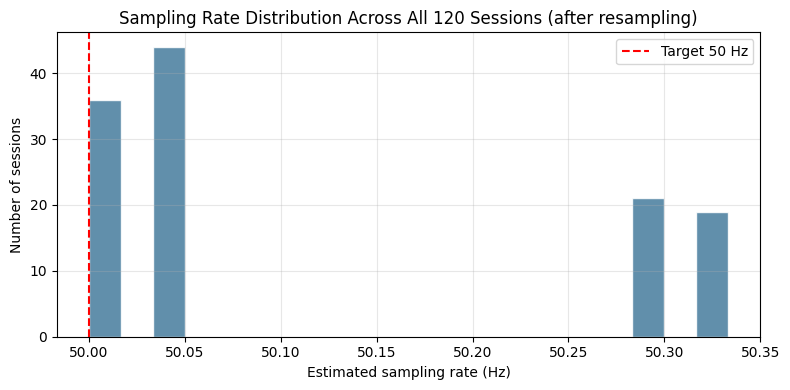

In [56]:
n_rows = df.groupby(["subject","activity","session"]).size()
hz_est = (n_rows / TARGET_SECONDS).reset_index(name="hz")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(hz_est["hz"], bins=20, color="#457b9d", edgecolor="white", alpha=0.85)
ax.axvline(50, color="red", linestyle="--", linewidth=1.5, label="Target 50 Hz")
ax.set_xlabel("Estimated sampling rate (Hz)")
ax.set_ylabel("Number of sessions")
ax.set_title("Sampling Rate Distribution Across All 120 Sessions (after resampling)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/eda/sampling_rate_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 6 · Low-Pass Butterworth Filter

**Why filter (ML4QS Ch. 3):**

Even after downsampling to 50 Hz, residual high-frequency sensor noise above ~12 Hz remains. This noise does not correspond to deliberate wrist motion — it is electrical noise and micro-vibrations from the phone hardware. Including it would artificially inflate features like std and RMS.

**Why Butterworth:** Maximally flat passband — no ripple in the 0–12 Hz motion band, preserving signal shape.

**Why `filtfilt` (zero-phase):** A causal filter introduces phase shift, which distorts the timing relationships between axes. `filtfilt` applies the filter forward and backward, achieving zero phase shift and preserving the directional information in the signal.

**Cutoff at 12 Hz:** Justified directly from our FFT analysis — all activity energy is below 12 Hz (cooking ~2.6 Hz, typing ~2.2 Hz, exercising ~0.6 Hz). 12 Hz gives a comfortable margin above the highest activity frequency.


### 6.1 · Visualise — Before vs After Preprocessing

In [57]:
# Run these one by one to find where labels die
print("after trim:", "subject" in df.columns)

# Re-check what apply_lowpass_filter returns
def apply_lowpass_filter(df: pd.DataFrame,
                          cutoff_hz: float = 12.0,
                          fs: float = 50.0,
                          order: int = 4) -> pd.DataFrame:
    results = []
    b, a = butter(order, cutoff_hz / (fs / 2.0), btype="low", analog=False)

    for subject in df["subject"].unique():
        for activity in df["activity"].unique():
            for session in df["session"].unique():
                mask = (
                    (df["subject"]  == subject) &
                    (df["activity"] == activity) &
                    (df["session"]  == session)
                )
                grp = df[mask].copy()
                if len(grp) == 0:
                    continue
                for col in SENSOR_COLS:
                    if len(grp) > 3 * order:
                        grp[col] = filtfilt(b, a, grp[col].values)
                grp["subject"]  = subject
                grp["activity"] = activity
                grp["session"]  = session
                results.append(grp)

    out = pd.concat(results, ignore_index=True)
    print(f"✅ Butterworth low-pass applied (cutoff={cutoff_hz} Hz, order={order}, zero-phase)")
    print(f"   Columns after filter: {out.columns.tolist()}")
    return out

df = apply_lowpass_filter(df, cutoff_hz=12.0, fs=50.0, order=4)
print(df.columns.tolist())

after trim: True
✅ Butterworth low-pass applied (cutoff=12.0 Hz, order=4, zero-phase)
   Columns after filter: ['time', 'acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z', 'lin_x', 'lin_y', 'lin_z', 'subject', 'activity', 'session']
['time', 'acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z', 'lin_x', 'lin_y', 'lin_z', 'subject', 'activity', 'session']


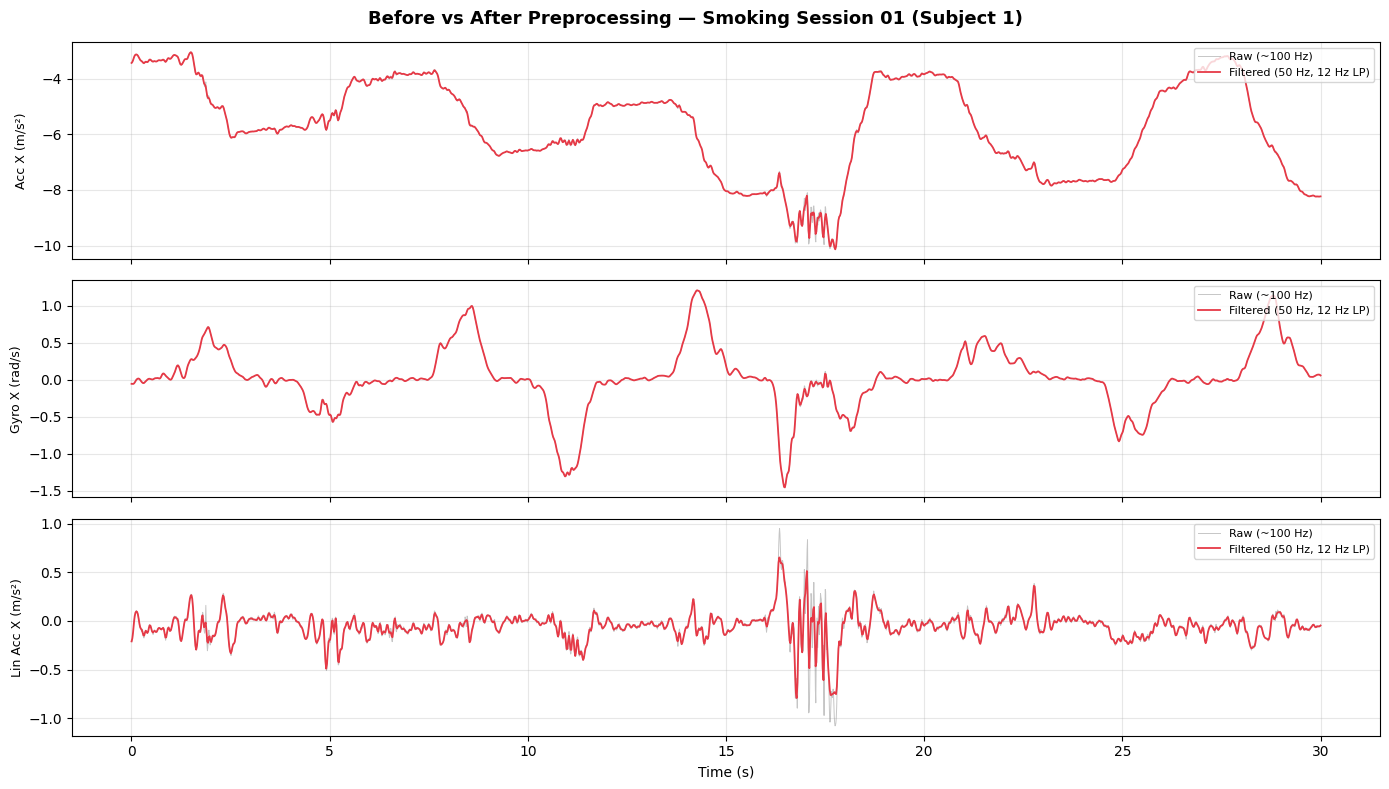

In [58]:
# Load raw session for comparison
raw_sample = load_session(DATA_DIR / "subject_1" / "smoking" / "session_01")
raw_sample = trim_to_duration(raw_sample)

clean_sample = df[
    (df["subject"]  == "subject_1") &
    (df["activity"] == "smoking") &
    (df["session"]  == "session_01")
].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Before vs After Preprocessing — Smoking Session 01 (Subject 1)",
             fontsize=13, fontweight="bold")

for ax, col, ylabel in zip(axes,
                            ["acc_x","gyr_x","lin_x"],
                            ["Acc X (m/s²)","Gyro X (rad/s)","Lin Acc X (m/s²)"]):
    ax.plot(raw_sample["time"], raw_sample[col],
            alpha=0.45, linewidth=0.7, color="grey", label="Raw (~100 Hz)")
    ax.plot(clean_sample["time"], clean_sample[col],
            linewidth=1.3, color="#e63946", label="Filtered (50 Hz, 12 Hz LP)")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig("outputs/eda/preprocessing_before_after.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.2 · Visualise — FFT Before vs After Filtering

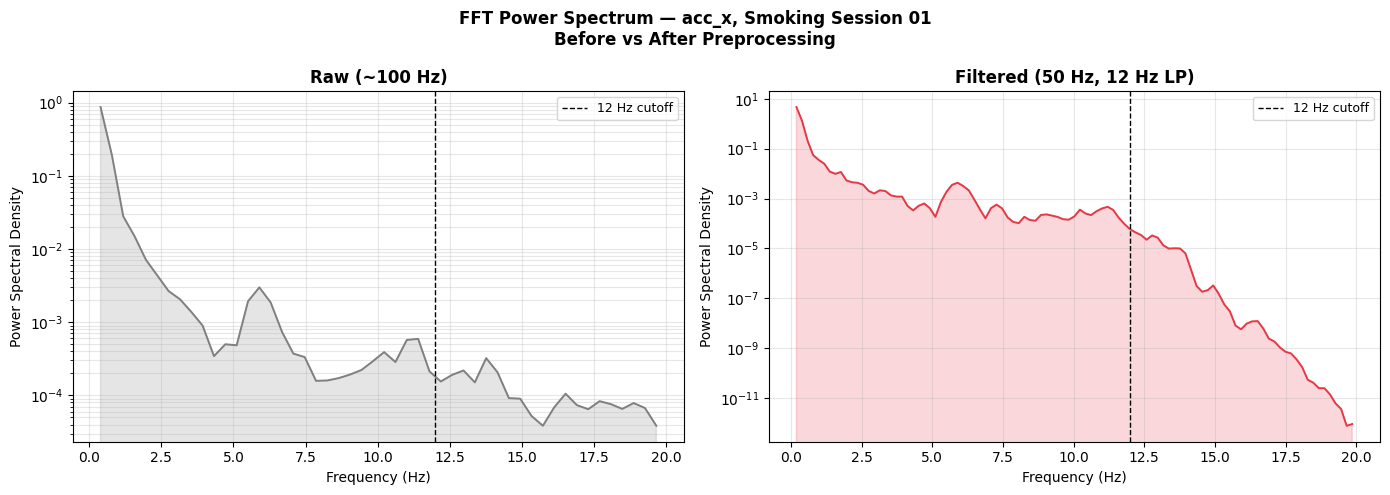

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("FFT Power Spectrum — acc_x, Smoking Session 01\nBefore vs After Preprocessing",
             fontsize=12, fontweight="bold")

for ax, signal_vals, label, color in zip(
    axes,
    [raw_sample["acc_x"].values,
     clean_sample["acc_x"].values],
    ["Raw (~100 Hz)", "Filtered (50 Hz, 12 Hz LP)"],
    ["grey", "#e63946"]
):
    signal_vals = signal_vals - np.mean(signal_vals)   # remove DC offset
    fs_local = len(signal_vals) / TARGET_SECONDS
    freqs, psd = welch(signal_vals, fs=fs_local, nperseg=256, noverlap=128)
    mask = (freqs >= 0.1) & (freqs <= 20)
    ax.semilogy(freqs[mask], psd[mask], color=color, linewidth=1.4)
    ax.fill_between(freqs[mask], psd[mask], alpha=0.2, color=color)
    ax.axvline(12, color="black", linestyle="--", linewidth=1, label="12 Hz cutoff")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power Spectral Density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("outputs/eda/fft_before_after_filter.png", dpi=150, bbox_inches="tight")
plt.show()


## 7 · Add Magnitude Columns

Resultant vector magnitudes are **rotation-invariant** — they capture the overall intensity of motion regardless of phone orientation. This is important for cross-person generalisation since participants may wear the phone at slightly different angles.


In [60]:
df["acc_mag"] = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
df["gyr_mag"] = np.sqrt(df["gyr_x"]**2 + df["gyr_y"]**2 + df["gyr_z"]**2)
df["lin_mag"] = np.sqrt(df["lin_x"]**2 + df["lin_y"]**2 + df["lin_z"]**2)

print("✅ Magnitude columns added")
df[["acc_mag","gyr_mag","lin_mag"]].describe().round(4)

✅ Magnitude columns added


,acc_mag,gyr_mag,lin_mag
count,180423.0000,180423.0000,180423.0000
mean,9.9153,0.6986,1.1077
std,1.3226,0.9056,1.5133
min,0.7020,0.0001,0.0003
25%,9.7331,0.0352,0.0958
50%,9.8554,0.2900,0.5078
75%,10.0962,1.1007,1.5467
max,23.5891,8.7169,18.4947


## 8 · Z-Score Normalisation

**Why normalise per subject (report section 3.4, ML4QS Ch. 3):**

Our EDA showed that absolute magnitudes differ across subjects for the same activity — one participant has a more vigorous cooking style, another holds the phone at a slightly different wrist angle. Normalising per subject removes these individual biases so the model learns activity-specific motion patterns, not person-specific scale differences.

**Why z-score over min-max:**
Min-max is sensitive to outliers — a single extreme value compresses all other values toward zero. Z-score is more robust and is the standard choice for distance-based classifiers (SVM, kNN).

**Critical — fit stats on train subjects only:**
We compute mean and std from subject_1 and subject_3 only, then apply those same parameters to subject_2 (test set). Computing normalisation stats on the test set would constitute data leakage.


In [61]:
NORM_COLS = SENSOR_COLS + ["acc_mag","gyr_mag","lin_mag"]

def normalise(df: pd.DataFrame) -> pd.DataFrame:
    df         = df.copy()
    train_mask = df["subject"].isin(["subject_1","subject_3"])
    train_df   = df[train_mask]

    # Fit and apply to each train subject individually
    for subj in ["subject_1","subject_3"]:
        subj_mask = df["subject"] == subj
        for col in NORM_COLS:
            mu  = train_df.loc[train_df["subject"]==subj, col].mean()
            std = train_df.loc[train_df["subject"]==subj, col].std()
            std = std if std > 1e-8 else 1.0
            df.loc[subj_mask, col] = (df.loc[subj_mask, col] - mu) / std

    # Apply pooled train stats to test subject (subject_2)
    for col in NORM_COLS:
        mu  = train_df[col].mean()
        std = train_df[col].std()
        std = std if std > 1e-8 else 1.0
        test_mask = df["subject"] == "subject_2"
        df.loc[test_mask, col] = (df.loc[test_mask, col] - mu) / std

    print("✅ Z-score normalisation applied (train stats from subject_1 + subject_3 only)")
    return df


df = normalise(df)

# Verify: train subjects should have mean ≈ 0 and std ≈ 1
print("\nNormalisation check — acc_x stats by subject:")
print(df.groupby("subject")["acc_x"].agg(["mean","std"]).round(4))


✅ Z-score normalisation applied (train stats from subject_1 + subject_3 only)

Normalisation check — acc_x stats by subject:
             mean     std
subject                  
subject_1 -0.0000  1.0000
subject_2 -0.9603  0.3781
subject_3  0.0000  1.0000


## 9 · Train / Test Split

**Split by person, not randomly (ML4QS Ch. 4, Hammerla et al. 2016):**

A random row-level split leaks information — adjacent rows in the same session are only 20 ms apart and nearly identical, so the model trivially memorises training sessions and reports inflated accuracy. A person-based split tests genuine generalisation to an unseen individual, which is the realistic deployment scenario for a wellbeing app.

| Split | Subjects | Sessions | Expected rows |
|---|---|---|---|
| Train | subject_1 + subject_3 | 80 | ~120,000 |
| Test | subject_2 | 40 | ~60,000 |


In [ ]:
train_df = df[df["subject"].isin(["subject_1","subject_3"])].copy()
test_df  = df[df["subject"] == "subject_2"].copy()

print(f"Train: {len(train_df):,} rows | "
      f"{train_df.groupby(['subject','activity','session']).ngroups} sessions")
print(f"Test:  {len(test_df):,} rows  | "
      f"{test_df.groupby(['subject','activity','session']).ngroups} sessions")

print(f"\nClass balance (train sessions):")
print(train_df.groupby(["activity","subject","session"]).ngroups /
      len(ACTIVITIES), "sessions per class (expected 16)")


Train: 120,383 rows | 80 sessions
Test:  60,040 rows  | 40 sessions

Class balance (train sessions):
16.0 sessions per class per subject (expected 8)


## 10 · Final Sanity Checks

In [63]:
print("="*55)
print("FINAL DATASET SUMMARY")
print("="*55)

for label, d in [("Full", df), ("Train", train_df), ("Test", test_df)]:
    dur    = d.groupby(["subject","activity","session"])["time"].max()
    n_sess = d.groupby(["subject","activity","session"]).ngroups
    print(f"\n{label}:")
    print(f"  Rows     : {len(d):,}")
    print(f"  Sessions : {n_sess}")
    print(f"  Duration : min={dur.min():.2f}s  max={dur.max():.2f}s  mean={dur.mean():.2f}s")
    print(f"  NaNs     : {d[SENSOR_COLS].isnull().sum().sum()}")

print("\nActivity distribution (sessions) in train:")
print(train_df.groupby(["activity","subject","session"]).size()
               .reset_index().groupby("activity").size())


FINAL DATASET SUMMARY

Full:
  Rows     : 180,423
  Sessions : 120
  Duration : min=29.98s  max=30.00s  mean=29.99s
  NaNs     : 0

Train:
  Rows     : 120,383
  Sessions : 80
  Duration : min=29.98s  max=30.00s  mean=29.99s
  NaNs     : 0

Test:
  Rows     : 60,040
  Sessions : 40
  Duration : min=29.98s  max=29.99s  mean=29.99s
  NaNs     : 0

Activity distribution (sessions) in train:
activity
cooking       16
exercising    16
idle          16
smoking       16
typing        16
dtype: int64


## 11 · Save Outputs

In [64]:
df.to_parquet("outputs/features/cleaned_all.parquet", index=False)
train_df.to_parquet("outputs/features/train.parquet",   index=False)
test_df.to_parquet("outputs/features/test.parquet",     index=False)

print("✅ Saved:")
print("  outputs/features/cleaned_all.parquet")
print("  outputs/features/train.parquet")
print("  outputs/features/test.parquet")
print(f"\nNext step → 02_feature_extraction.ipynb")

✅ Saved:
  outputs/features/cleaned_all.parquet
  outputs/features/train.parquet
  outputs/features/test.parquet

Next step → 02_feature_extraction.ipynb
